In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
accessdf = pd.read_csv('Access_LiverpoolLGA_Uniform.csv')
accessdf.head()

,locality,Jobs,cutoff,X,T_freq,L_freq
0,Liverpool,4675.974992,15,1,0.0,1.0
1,Liverpool,40539.922655,30,1,0.0,1.0
2,Liverpool,154535.993446,45,1,0.0,1.0
3,Liverpool,516845.375888,60,1,0.0,1.0
4,Liverpool,4508.858989,15,2,0.0,2.0


In [3]:
accessdf['T_freqPerHr'] = accessdf['T_freq'].apply(lambda x: 0 if x==0 else 60/x).astype(int)
accessdf['L_freqPerHr'] = accessdf['L_freq'].apply(lambda x: 0 if x==0 else 60/x).astype(int)
accessdf.columns = ['locality','Jobs','cutoff','X','T_f','L_f','T_freq','L_freq']
accessdf.head()

,locality,Jobs,cutoff,X,T_f,L_f,T_freq,L_freq
0,Liverpool,4675.974992,15,1,0.0,1.0,0,60
1,Liverpool,40539.922655,30,1,0.0,1.0,0,60
2,Liverpool,154535.993446,45,1,0.0,1.0,0,60
3,Liverpool,516845.375888,60,1,0.0,1.0,0,60
4,Liverpool,4508.858989,15,2,0.0,2.0,0,30


In [4]:
access15 = accessdf.loc[accessdf['cutoff']==15]
access15 = access15[['T_freq','L_freq','Jobs']]
access15 = access15.pivot('T_freq','L_freq')

access30 = accessdf.loc[accessdf['cutoff']==30]
access30 = access30[['T_freq','L_freq','Jobs']]
access30 = access30.pivot('T_freq','L_freq')

access45 = accessdf.loc[accessdf['cutoff']==45]
access45 = access45[['T_freq','L_freq','Jobs']]
access45 = access45.pivot('T_freq','L_freq')

access60 = accessdf.loc[accessdf['cutoff']==60]
access60 = access60[['T_freq','L_freq','Jobs']]
access60 = access60.pivot('T_freq','L_freq')

In [5]:
X = access15.columns.levels[1].values
Y = access15.index.values

Z15 = access15.values
Z30 = access30.values
Z45 = access45.values
Z60 = access60.values

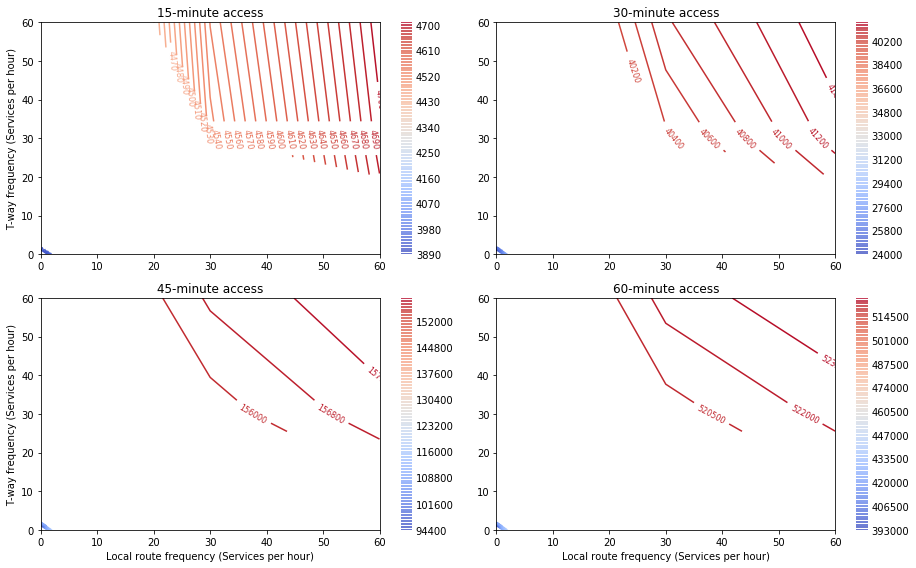

In [36]:
Xi,Yi = np.meshgrid(X,Y)

plt.rcParams["figure.figsize"] = (13,8)

fig = plt.figure()

ax1 = fig.add_subplot(221)
cplot15 = plt.contour(Xi,Yi,Z15,100,cmap='coolwarm')
plt.clabel(cplot15, inline=True, fmt='%1.0f', fontsize=8)
plt.ylabel('T-way frequency (Services per hour)')
ax1.title.set_text('15-minute access')
cb = plt.colorbar()
cb.outline.set_visible(False)
cb.ax.tick_params(size=0)

ax2 = fig.add_subplot(222)
cplot30 = plt.contour(Xi,Yi,Z30,100,cmap='coolwarm')
plt.clabel(cplot30, inline=True, fmt='%1.0f', fontsize=8)
ax2.title.set_text('30-minute access')
cb = plt.colorbar()
cb.outline.set_visible(False)
cb.ax.tick_params(size=0)

ax3 = fig.add_subplot(223)
cplot45 = plt.contour(Xi,Yi,Z45,100,cmap='coolwarm')
plt.clabel(cplot45, inline=True, fmt='%1.0f', fontsize=8)
plt.xlabel('Local route frequency (Services per hour)')
plt.ylabel('T-way frequency (Services per hour)')
ax3.title.set_text('45-minute access')
cb = plt.colorbar()
cb.outline.set_visible(False)
cb.ax.tick_params(size=0)

ax4 = fig.add_subplot(224)
cplot60 = plt.contour(Xi,Yi,Z60,100,cmap='coolwarm')
plt.clabel(cplot60, inline=True, fmt='%1.0f', fontsize=8)
plt.xlabel('Local route frequency (Services per hour)')
ax4.title.set_text('60-minute access')
cb = plt.colorbar()
cb.outline.set_visible(False)
cb.ax.tick_params(size=0)

fig.tight_layout()
plt.show()
fig.savefig('./Plots/IsoAccess_All.pdf')


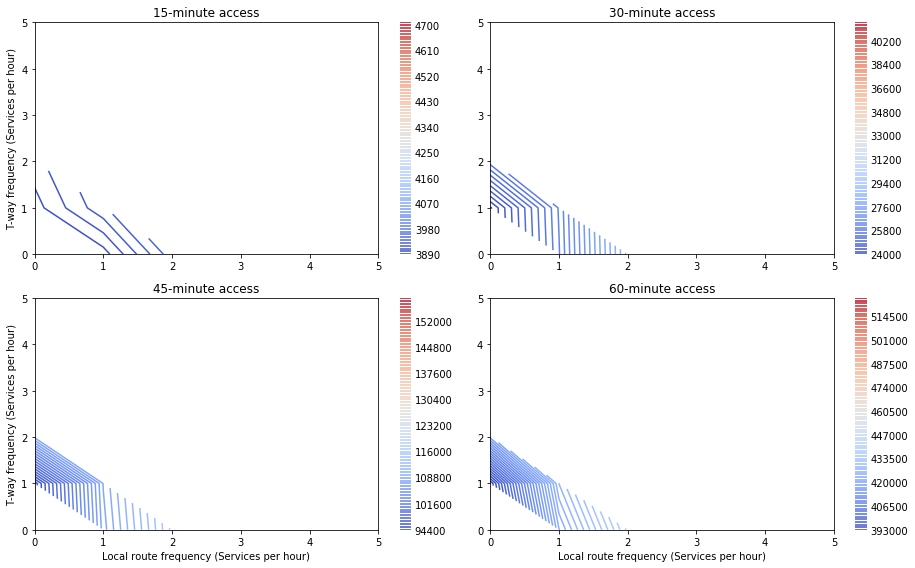

In [35]:
Xi,Yi = np.meshgrid(X,Y)

plt.rcParams["figure.figsize"] = (13,8)

fig = plt.figure()

ax1 = fig.add_subplot(221)
cplot15 = plt.contour(Xi,Yi,Z15,100,cmap='coolwarm')
plt.clabel(cplot15, inline=True, fmt='%1.0f', fontsize=8)
plt.xlim(0,5)
plt.ylim(0,5)
plt.ylabel('T-way frequency (Services per hour)')
ax1.title.set_text('15-minute access')
cb = plt.colorbar()
cb.outline.set_visible(False)
cb.ax.tick_params(size=0)

ax2 = fig.add_subplot(222)
cplot30 = plt.contour(Xi,Yi,Z30,100,cmap='coolwarm')
plt.clabel(cplot30, inline=True, fmt='%1.0f', fontsize=8)
plt.xlim(0,5)
plt.ylim(0,5)
ax2.title.set_text('30-minute access')
cb = plt.colorbar()
cb.outline.set_visible(False)
cb.ax.tick_params(size=0)

ax3 = fig.add_subplot(223)
cplot45 = plt.contour(Xi,Yi,Z45,100,cmap='coolwarm')
plt.clabel(cplot45, inline=True, fmt='%1.0f', fontsize=8)
plt.xlim(0,5)
plt.ylim(0,5)
plt.xlabel('Local route frequency (Services per hour)')
plt.ylabel('T-way frequency (Services per hour)')
ax3.title.set_text('45-minute access')
cb = plt.colorbar()
cb.outline.set_visible(False)
cb.ax.tick_params(size=0)

ax4 = fig.add_subplot(224)
cplot60 = plt.contour(Xi,Yi,Z60,100,cmap='coolwarm')
plt.clabel(cplot60, inline=True, fmt='%1.0f', fontsize=8)
plt.xlim(0,5)
plt.ylim(0,5)
plt.xlabel('Local route frequency (Services per hour)')
ax4.title.set_text('60-minute access')
cb = plt.colorbar()
cb.outline.set_visible(False)
cb.ax.tick_params(size=0)

fig.tight_layout()
plt.show()
fig.savefig('./Plots/IsoAccess_Under5.pdf')
